# Model Building

**Models**: Logistic Regression, Decision Tree, Random Forest, SVC and KNN

### 1) Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,classification_report)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

### 2) Load Cleaned Data

In [5]:
df = pd.read_csv('data.csv')
print(f" Shape: {df.shape}")
df.head()

 Shape: (852, 12)


,age,sex,bmi,systolic_pressure,glucose,cholesterol,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,36,0,26.3,100,70,222,0,1,0,0,0,0
1,52,0,24.6,138,108,213,1,1,1,0,0,0
2,52,0,28.7,118,70,164,0,1,0,0,0,0
3,65,1,19.7,147,72,229,1,2,0,0,0,1
4,31,1,26.0,107,124,160,0,0,0,0,0,0


### 3) Prepare Features and Target

In [8]:
base_features = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol', 'smoking', 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']

# Features de interação
df['bmi_smoking'] = df['bmi'] * df['smoking']
df['age_family_diabetes'] = df['age'] * df['family_history_diabetes']
df['age_family_hypertension'] = df['age'] * df['family_history_hypertension']
df['glucose_cholesterol'] = df['glucose'] * df['cholesterol'] / 1000
df['bmi_physical'] = df['bmi'] * (2 - df['physical_activity'])

# Features categóricas
df['bmi_obese'] = (df['bmi'] >= 30).astype(int)
df['bp_high'] = (df['systolic_pressure'] >= 130).astype(int)
df['glucose_high'] = (df['glucose'] >= 100).astype(int)
df['cholesterol_high'] = (df['cholesterol'] >= 200).astype(int)
df['age_senior'] = (df['age'] >= 60).astype(int)

interaction_features = ['bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                        'glucose_cholesterol', 'bmi_physical']
categorical_features = ['bmi_obese', 'bp_high', 'glucose_high', 
                        'cholesterol_high', 'age_senior']

all_features = base_features + interaction_features + categorical_features

X = df[all_features].copy()
y_diabetes = df['diabetes_risk']
y_hypertension = df['hypertension_risk']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Targets:")
print(f"-Diabetes: {y_diabetes.sum()} positives ({y_diabetes.mean()*100:.1f}%)")
print(f"-Hypertension: {y_hypertension.sum()} positives ({y_hypertension.mean()*100:.1f}%)")

X_train, X_test, y_diab_train, y_diab_test = train_test_split(X, y_diabetes, test_size=0.2, random_state=67, stratify=y_diabetes)

_, _, y_hyp_train, y_hyp_test = train_test_split(X, y_hypertension, test_size=0.2, random_state=67, stratify=y_hypertension)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Feature scaling

numeric_features = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol',
                    'bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                    'glucose_cholesterol', 'bmi_physical']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# SMOTE balancing (SVM and KNN)
smote_diab = SMOTE(random_state=67)
X_train_balanced_diab, y_diab_train_balanced = smote_diab.fit_resample(X_train_scaled, y_diab_train)

smote_hyp = SMOTE(random_state=67)
X_train_balanced_hyp, y_hyp_train_balanced = smote_hyp.fit_resample(X_train_scaled, y_hyp_train)

Features: 19
Samples: 852
Targets:
-Diabetes: 182 positives (21.4%)
-Hypertension: 314 positives (36.9%)
Train: 681 samples
Test: 171 samples


### 4) Train Models

In [13]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=67, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=67, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=67),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=67),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

diabetes_models = {}
hypertension_models = {}
diabetes_results = []
hypertension_results = []
print("-"*50)
print("Training models for Diabetes:")
print("-"*50)
# Diabetes models
for name, model in models.items():
    print(f"Training {name}...")
    
    # SVM and KNN use SMOTE
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_diab, y_diab_train_balanced)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_scaled, y_diab_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_diab_test, y_pred)
    prec = precision_score(y_diab_test, y_pred)
    rec = recall_score(y_diab_test, y_pred)
    f1 = f1_score(y_diab_test, y_pred)
    auc = roc_auc_score(y_diab_test, y_proba)
    
    diabetes_models[name] = model
    diabetes_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f} \n")

print("-"*50)
print("Training models for Hypertension:")
print("-"*50)
# Hypertension models
for name, model in models.items():
    print(f"Training {name}...")
    
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_hyp, y_hyp_train_balanced)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_scaled, y_hyp_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_hyp_test, y_pred)
    prec = precision_score(y_hyp_test, y_pred)
    rec = recall_score(y_hyp_test, y_pred)
    f1 = f1_score(y_hyp_test, y_pred)
    auc = roc_auc_score(y_hyp_test, y_proba)
    
    hypertension_models[name] = model
    hypertension_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f}")

--------------------------------------------------
Training models for Diabetes:
--------------------------------------------------
Training Logistic Regression...
Accuracy: 0.7953 | ROC-AUC: 0.8461 | F1: 0.5882 

Training Decision Tree...
Accuracy: 0.7778 | ROC-AUC: 0.6364 | F1: 0.4412 

Training Random Forest...
Accuracy: 0.8129 | ROC-AUC: 0.8095 | F1: 0.4839 

Training SVM...
Accuracy: 0.7719 | ROC-AUC: 0.7908 | F1: 0.4935 

Training KNN...
Accuracy: 0.7485 | ROC-AUC: 0.7475 | F1: 0.5057 

--------------------------------------------------
Training models for Hypertension:
--------------------------------------------------
Training Logistic Regression...
Accuracy: 0.5380 | ROC-AUC: 0.5486 | F1: 0.4317
Training Decision Tree...
Accuracy: 0.5439 | ROC-AUC: 0.5484 | F1: 0.4507
Training Random Forest...
Accuracy: 0.6140 | ROC-AUC: 0.5398 | F1: 0.3400
Training SVM...
Accuracy: 0.5380 | ROC-AUC: 0.5117 | F1: 0.4476
Training KNN...
Accuracy: 0.5263 | ROC-AUC: 0.5087 | F1: 0.3721


### 5) Model Comparison


DIABETES RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.846107  0.588235 0.675676   0.520833
      Decision Tree 0.636446  0.441176 0.405405   0.483871
      Random Forest 0.809500  0.483871 0.405405   0.600000
                SVM 0.790843  0.493506 0.513514   0.475000
                KNN 0.747479  0.505747 0.594595   0.440000

HYPERTENSION RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.548648  0.431655 0.476190   0.394737
      Decision Tree 0.548354  0.450704 0.507937   0.405063
      Random Forest 0.539830  0.340000 0.269841   0.459459
                SVM 0.511684  0.447552 0.507937   0.400000
                KNN 0.508671  0.372093 0.380952   0.363636


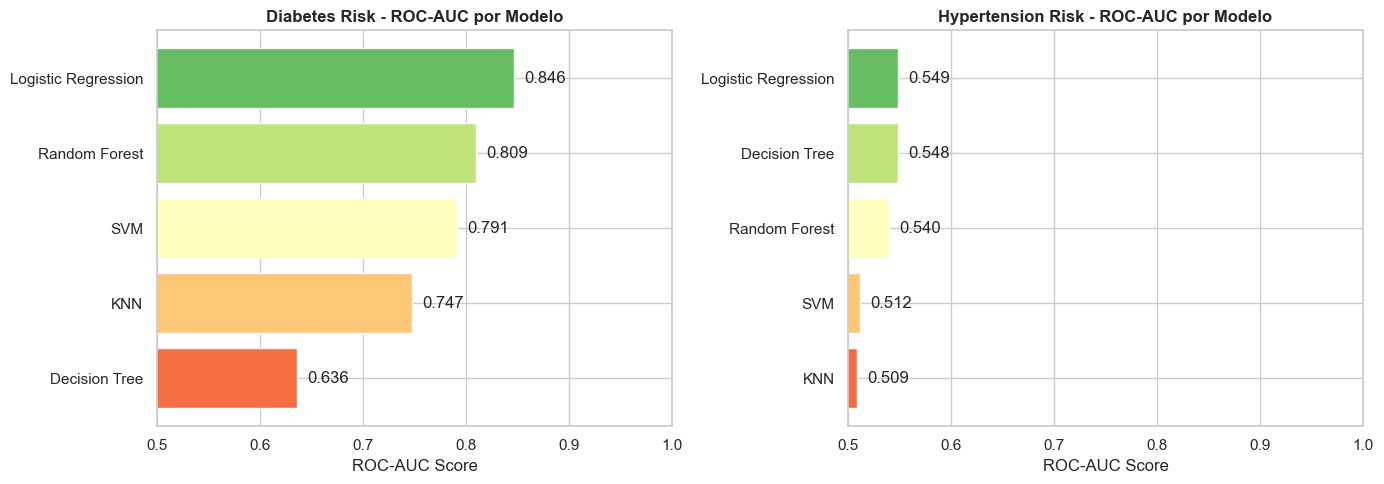

In [19]:
diab_df = pd.DataFrame(diabetes_results)
hyp_df = pd.DataFrame(hypertension_results)

best_diab_model = diab_df.loc[diab_df['ROC-AUC'].idxmax(), 'Model']
best_diab_auc = diab_df['ROC-AUC'].max()

best_hyp_model = hyp_df.loc[hyp_df['ROC-AUC'].idxmax(), 'Model']
best_hyp_auc = hyp_df['ROC-AUC'].max()

print("\n" + "="*60)
print("DIABETES RISK - Models Performance")
print("="*60)
print(diab_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

print("\n" + "="*60)
print("HYPERTENSION RISK - Models Performance")
print("="*60)
print(hyp_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diabetes
ax = axes[0]
diab_sorted = diab_df.sort_values('ROC-AUC', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(diab_sorted)))
bars = ax.barh(diab_sorted['Model'], diab_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Diabetes Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, diab_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Hypertension
ax = axes[1]
hyp_sorted = hyp_df.sort_values('ROC-AUC', ascending=True)
bars = ax.barh(hyp_sorted['Model'], hyp_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Hypertension Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, hyp_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()